In [44]:
import sys
sys.path.insert(0, '../../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [45]:
participants = pd.read_csv(SNHL_ROOT / 'participants.tsv', sep='\t')
participants.head()

,participant_id,age,hearing_status,ear_eeg,handedness,gender,speech_reception_thresholds,digit_span_backward,digit_span_forward,FT_test_temporal,...,audiogram_right_ear_8000Hz,audiogram_left_ear_125Hz,audiogram_left_ear_250Hz,audiogram_left_ear_500Hz,audiogram_left_ear_1000Hz,audiogram_left_ear_2000Hz,audiogram_left_ear_3000Hz,audiogram_left_ear_4000Hz,audiogram_left_ear_6000Hz,audiogram_left_ear_8000Hz
0,sub-001,71,hi,Yes,L,M,-1.900000,19,23,8.560636,...,90,20,15,15,20,45,70,80,80,75
1,sub-002,56,hi,Yes,L,F,-3.066667,10,16,-1.592565,...,85,15,10,10,25,50,75,80,90,85
2,sub-003,66,hi,Yes,R,M,-3.266667,11,16,-0.238726,...,95,15,10,5,10,20,50,80,80,80
3,sub-004,74,hi,Yes,R,F,-2.966667,12,27,-1.734571,...,65,25,10,10,10,15,25,40,60,70
4,sub-005,70,hi,Yes,R,M,-2.533333,16,18,3.190100,...,75,10,15,15,25,40,60,50,65,80


In [46]:
# Load subjects -----------------------------------

nh_subjects = participants[participants['hearing_status'] == 'nh']['participant_id'].tolist()
hi_subjects = participants[participants['hearing_status'] == 'hi']['participant_id'].tolist()

print("NH SUBJECTS: ", nh_subjects)
print("HI SUBJECTS:", hi_subjects)

print("NH SUBJECTS: ", len(nh_subjects))
print("HI SUBJECTS:", len(hi_subjects))

NH SUBJECTS:  ['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-043', 'sub-044']
HI SUBJECTS: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-041', 'sub-042']
NH SUBJECTS:  22
HI SUBJECTS: 22


## Functions

In [47]:
# Load envelope from matfile to NDVAR -----------------------------------

def load_envelope_ndvar(mat_path):
    mat = scipy.io.loadmat(str(mat_path))["dat"]
    
    feat = mat['feat'][0][0].squeeze()   # 1D envelope
    #print("feat:", feat)
    fs = mat['fs'][0][0][0][0]
    t    = mat['t'][0][0].squeeze()      # time vector re trial onset
    #print("t: ", t)
    
    # Build Eelbrain time dimension from the t vector
    time_dim = eelbrain.UTS(t[0], 1/fs, len(feat))
    
    
    env = eelbrain.NDVar(feat, dims=(time_dim,), name='envelope')
    env = eelbrain.resample(env, 64) # resample to EEG
    env = eelbrain.filter_data(env, 0.5, 20) # filter to same as EEG
    return env

In [48]:
# Load attended and ignored envelopes specific to subject and trial -----------------------------------

def load_trial_envelopes(subject_id, trial, is_hi=False):
    subject = subject_id.replace('-', '') # change subject_id from "sub-001" -> "sub001"

    sub_stim_dir = SNHL_IMPORTED_ENVELOPES_DIR / subject

    # Extract trial number from stim_file (e.g. 'sub001/target/t004.wav' → 't004')
    trial_num = Path(trial['stim_file']).stem  # e.g. 't004'
    masker_num = Path(trial['masker_stim_file']).stem  # e.g. 'm004'

    # For HI subjects: use 'woa' files (without CamEQ) to match NH
    suffix = "" if is_hi else ""
    
    target_path = sub_stim_dir / 'target' / f'{trial_num}{suffix}.mat'
    masker_path = sub_stim_dir / 'masker' / f'{masker_num}{suffix}.mat'

    env_attended = load_envelope_ndvar(target_path)
    env_ignored  = load_envelope_ndvar(masker_path)

    return env_attended, env_ignored
        

In [49]:
def load_predictors_for_trial(subject_id, trial):
    # load envelopes
    env_attended = helper_functions.load_predictor_snhl(subject_id, trial['stim_file'], role='target', predictor_type=PREDICTOR_TYPE.ENVELOPE)
    env_ignored  = helper_functions.load_predictor_snhl(subject_id, trial['masker_stim_file'], role='masker', predictor_type=PREDICTOR_TYPE.ENVELOPE)
    
    # Load onsets
    onsets_attended = helper_functions.load_predictor_snhl(subject_id, trial['stim_file'], role='target', predictor_type=PREDICTOR_TYPE.ENVELOPE_ONSET)
    onsets_ignored  = helper_functions.load_predictor_snhl(subject_id, trial['masker_stim_file'], role='masker', predictor_type=PREDICTOR_TYPE.ENVELOPE_ONSET)
    
    return {
        'env_attended': env_attended,
        'env_ignored': env_ignored,
        'onsets_attended': onsets_attended,
        'onsets_ignored': onsets_ignored
    }


In [50]:
# Load full selective attention EEG for subject -----------------------------------

def load_eeg(subject_id):
    bdf_path = SNHL_ROOT / subject_id / 'eeg' / f'{subject_id}_task-selectiveattention_eeg.bdf'
    raw = mne.io.read_raw_bdf(str(bdf_path), preload=True)  # 512 Hz

    # 1. Rereference
    raw.set_eeg_reference(['TP7', 'TP8'])

    # 2. Skip ICA

    # 3. Filter
    raw.filter(0.5, 20.0)

    # 4. Interpolate bad channels
    # no bad channels

    # 5. Resample
    raw.resample(64)

    # 6. Drop auxiliary channels
    raw.drop_channels(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8'])
    raw.pick_types(eeg=True)

    return raw

In [51]:
# Convert EEG data from raw to NDVAR -----------------------------------

def eeg_trial_to_ndvar(raw, trial, trf_sensor_dim):
    orig_sfreq = 512
    sfreq = raw.info['sfreq'] # 64 Hz after resampling

    start_sample = int(trial['sample']     * sfreq / orig_sfreq)
    end_sample   = int(trial['end_sample'] * sfreq / orig_sfreq)

    data = raw.get_data(start=start_sample, stop=end_sample)

    order = [raw.ch_names.index(ch) for ch in trf_sensor_dim.names]
    data  = data[order, :]

    # Time axis starts at 0 = target onset, matching envelope t vectors
    time_dim = eelbrain.UTS(0.0, 1/sfreq, data.shape[1])
    return eelbrain.NDVar(data, dims=(trf_sensor_dim, time_dim), name='eeg')

## AAD pipeline

In [52]:
# ── 1. LOAD ONE SUBJECT'S TRIAL DATA ────────────────────────────────────────

def load_subject_trials(subject_id, sensor_dim, is_hi=False, predictor_type=PREDICTOR_TYPE.ENVELOPE):
    """
    Load EEG + attended/ignored envelopes for every two-talker trial
    of one subject. Returns a list of trial dicts.

    Each dict contains:
        subject, group, trial, attend_side, difficulty, score,
        eeg (NDVar), attended (NDVar), ignored (NDVar)
    """
    print(f"Loading subject {subject_id} " + "─" * 45)

    raw    = load_eeg(subject_id)
    trials = helper_functions.get_trials_snhl(subject_id)
    print(f"  EEG : {len(raw.ch_names)} ch  |  {raw.info['sfreq']} Hz  |  {raw.times[-1]:.1f}s total")
    print(f"  Trials found: {len(trials)}")

    trial_data = []
    for _, trial in trials.iterrows():
        trial_name = Path(trial['stim_file']).stem
        try:
            # EEG
            eeg          = eeg_trial_to_ndvar(raw, trial, sensor_dim)
            
            # Self computed predictors (envelopes and onsets)
            predictors = load_predictors_for_trial(subject_id, trial)
            att = predictors['env_attended']
            ign = predictors['env_ignored']
            att_onsets = predictors['onsets_attended']
            ign_onsets = predictors['onsets_ignored']

            # Envelopes imported from matfiles (not self computed)
            #att, ign     = load_trial_envelopes(subject_id, trial, is_hi)
            

            # Ignored speech star 3-5 seconds after target speech, only include data from this point onward.
            t_start = float(ign.time.tmin) 
            t_stop  = min(float(eeg.time.tmax), float(att.time.tmax), float(ign.time.tmax))

            eeg         = eeg.sub(time=(t_start, t_stop))
            att         = att.sub(time=(t_start, t_stop))
            ign         = ign.sub(time=(t_start, t_stop))

            # align sample counts exactly
            n = min(eeg.shape[-1], att.shape[-1], ign.shape[-1])
            t_last = eeg.time[n - 1]
            eeg         = eeg.sub(time=(t_start, t_last))
            att         = att.sub(time=(t_start, t_last))
            ign         = ign.sub(time=(t_start, t_last))



            trial_data.append({
                'subject':     subject_id,
                'group':       'HI' if is_hi else 'NH',
                'trial':       trial['stim_file'],
                'attend_side': trial['attend_left_right'],
                'difficulty':  trial['difficulty'],
                'score':       trial['score'],
                'duration_s':  float(eeg.time.tmax - eeg.time.tmin),
                'eeg':         eeg,
                'attended':    att,
                'ignored':     ign,
            })
        except Exception as e:
            print(f"  ✗ skipping {trial_name}: {e}")

    print(f"  ✓ {len(trial_data)}/{len(trials)} trials loaded")
    
    durations = [t['duration_s'] for t in trial_data]
    print(f"  Trial durations: min={min(durations):.1f}s  max={max(durations):.1f}s  mean={np.mean(durations):.1f}s")
    print()
    
    return trial_data

In [53]:
# ── 2. GROUP TRIALS INTO WINDOWS ─────────────────────────────────────────────

def make_trial_windows(trial_data, window_size_in_trials):
    """
    Partition trial_data into non-overlapping windows of
    `window_size_in_trials` consecutive trials.
    Incomplete trailing windows are dropped.

    Returns a list of window-lists  →  [[trial, trial, ...], ...]
    Each inner list has exactly `window_size_in_trials` trial dicts.
    """
    n = len(trial_data)
    windows = [
        trial_data[start : start + window_size_in_trials]
        for start in range(0, n - window_size_in_trials + 1, window_size_in_trials)
    ]
    return windows


def make_time_windows(trial_data, window_duration_s):
    """
    Split each trial into non-overlapping time windows of `window_duration_s` seconds.
    !! NOTICE: Incomplete trailing windows are dropped. !!
    
    Returns a list of window dicts, each representing one time slice.
    Each window inherits the trial metadata (subject, attend_side, etc.)
    """
    windows = []

    for trial in trial_data:
        eeg = trial['eeg']
        att = trial['attended']
        ign = trial['ignored']

        t_start = float(eeg.time.tmin)
        t_end   = float(eeg.time.tmax)
        duration = t_end - t_start

        n_windows = int(duration // window_duration_s)

        for i in range(n_windows):
            seg_start = t_start + i * window_duration_s
            seg_end   = seg_start + window_duration_s

            windows.append({
                **trial,
                'eeg':         eeg.sub(time=(seg_start, seg_end)),
                'attended':    att.sub(time=(seg_start, seg_end)),
                'ignored':     ign.sub(time=(seg_start, seg_end)),
                'trial':       f"{trial['trial']}_seg{i:02d}",
                'window_dur':  window_duration_s,
                'seg_index':   i,
            })

    return windows

In [54]:
# ── 3. DECODE ONE TRIAL ───────────────────────────────────────────────────────

def decode_single_trial(trial_dict, trf, ):
    """
    Apply the backward TRF to one trial dict and return (decision, r_att, r_ign).
    Thin wrapper around aad_single_classifier so call sites stay readable.
    """
    decision, r_att, r_ign = helper_functions.aad_single_classifier(
        trial_dict['eeg'],
        true_att=trial_dict['attended'],
        true_ign=trial_dict['ignored'],
        trf=trf,
    )
    return bool(decision), float(r_att), float(r_ign)

In [55]:
# ── 4a. STRATEGY A — concatenate then correlate ───────────────────────────────

def decode_window_by_concatenation(window_trials, trf):
    """
    Concatenate all trials in the window into one long segment,
    then compute a single correlation → single decision.

    Strategy: concatenate → correlate → decide
    """
    eeg_cat = eelbrain.concatenate([t['eeg']      for t in window_trials])
    att_cat = eelbrain.concatenate([t['attended'] for t in window_trials])
    ign_cat = eelbrain.concatenate([t['ignored']  for t in window_trials])

    window_dict = {
        **window_trials[0],           # inherit subject/group metadata
        'trial':    f"window_{len(window_trials)}_trials",
        'eeg':      eeg_cat,
        'attended': att_cat,
        'ignored':  ign_cat,
    }
    return decode_single_trial(window_dict, trf)

In [56]:
# ── 4b. STRATEGY B — correlate then average ───────────────────────────────────

def decode_window_by_correlation_average(window_trials, trf):
    """
    Decode each trial in the window independently, then average r_att and r_ign
    across trials and make one decision from the averaged correlations.

    Strategy: correlate per trial → average r → decide

    This differs from concatenation because:
      - Each trial's correlation is normalised by its own variance
      - Short and long trials contribute equally to the average
      - Temporal structure across trial boundaries is not assumed
    """
    r_atts, r_igns = [], []
    for trial in window_trials:
        _, r_att, r_ign = decode_single_trial(trial, trf)
        r_atts.append(r_att)
        r_igns.append(r_ign)

    r_att_mean = float(np.mean(r_atts))
    r_ign_mean = float(np.mean(r_igns))
    decision   = r_att_mean > r_ign_mean

    return decision, r_att_mean, r_ign_mean, r_atts, r_igns

In [57]:
# ── 5. Make a result dict differentiating between strategy A and B ('concatenate' or 'average') ──────────────────────────────────────────────────────────

def _result_row_from_window(window_trials, trf, window_size, window_dur_s, strategy):
    """
    Decode one window with the requested strategy and return a result dict.
    `strategy` must be 'concatenate' or 'average'.
    """
    meta = {
        'subject':      window_trials[0]['subject'],
        'group':        window_trials[0]['group'],
        'window_size':  window_size,
        'window_dur_s': window_dur_s,
        'strategy':     strategy,
        'attend_side':  window_trials[0]['attend_side'] if window_size == 1 else None,
        'difficulty':   window_trials[0]['difficulty']  if window_size == 1 else None,
        'score':        window_trials[0]['score']        if window_size == 1 else None,
    }

    if strategy == 'concatenate':
        decision, r_att, r_ign = decode_window_by_concatenation(window_trials, trf)
        return {**meta,
                'r_att':   r_att,
                'r_ign':   r_ign,
                'delta_r': r_att - r_ign,
                'correct': decision}

    elif strategy == 'average':
        decision, r_att, r_ign, r_atts, r_igns = \
            decode_window_by_correlation_average(window_trials, trf)
        return {**meta,
                'r_att':      r_att,
                'r_ign':      r_ign,
                'delta_r':    r_att - r_ign,
                'correct':    decision,
                'r_att_std':  float(np.std(r_atts)),
                'r_ign_std':  float(np.std(r_igns))}
    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Use 'concatenate' or 'average'.")


In [58]:
# ── 6. MAIN PIPELINE ──────────────────────────────────────────────────────────

TRIAL_WINDOW_SIZES   = [1, 2, 4, 8, 12, 16, 20, 24, 28, 32]        # in number of trials (~50s each)
TIME_WINDOW_SIZES_S  = [5, 10, 20, 30, 40]         # in seconds within a trial


def run_decoding_pipeline(subjects, trf, output_dir, is_hi=False,
                          trial_window_sizes=TRIAL_WINDOW_SIZES,
                          time_window_sizes_s=TIME_WINDOW_SIZES_S,
                          predictor_type=PREDICTOR_TYPE.ENVELOPE):

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    group = 'HI' if is_hi else 'NH'

    # collectors keyed by a label
    rows = {}
    for n in trial_window_sizes:
        rows[f'trials_{n}'] = {'concatenate': [], 'average': []}
    for dur in time_window_sizes_s:
        rows[f'time_{dur}s'] = {'concatenate': [], 'average': []}

    for subject in subjects:
        trial_data = load_subject_trials(subject, trf.h_scaled.sensor, is_hi=is_hi, predictor_type=predictor_type)
        if not trial_data:
            continue

        # ── multi-trial windows ───────────────────────────────────────────
        for n in trial_window_sizes:
            windows = make_trial_windows(trial_data, n)
            for window in windows:
                rows[f'trials_{n}']['concatenate'].append(
                    _result_row_from_window(window, trf, window_size=n,
                                           window_dur_s=n*50, strategy='concatenate')
                )
                rows[f'trials_{n}']['average'].append(
                    _result_row_from_window(window, trf, window_size=n,
                                           window_dur_s=n*50, strategy='average')
                )

        # ── sub-trial time windows ────────────────────────────────────────
        for dur in time_window_sizes_s:
            time_windows = make_time_windows(trial_data, dur)
            for w in time_windows:
                rows[f'time_{dur}s']['concatenate'].append(
                    _result_row_from_window([w], trf, window_size=1,
                                            window_dur_s=dur, strategy='concatenate')
                )

    # save — skip if file already exists
    results = {}
    for key, strategies in rows.items():
        results[key] = {}
        for strategy, row_list in strategies.items():
            if not row_list:
                continue
            path = output_dir / f'results_{group}_{key}_{strategy}_{predictor_type.value}.csv'

            if path.exists():
                print(f"  {group} | {key} | {strategy:<12} | already exists, skipping → {path.name}")
                results[key][strategy] = pd.read_csv(path)
                continue

            df = pd.DataFrame(row_list)
            df.to_csv(path, index=False)
            print(f"  {group} | {key} | {strategy:<12} | "
                  f"r_att={df['r_att'].mean():.4f}  "
                  f"r_ign={df['r_ign'].mean():.4f}  "
                  f"acc={df['correct'].mean():.1%}  → {path.name}")
            results[key][strategy] = df

    return results

In [59]:
# ── 7. CALL SITE ──────────────────────────────────────────────────────────────


# Envelope results
name = helper_functions.get_trf_model_name(
    DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE,
    ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD,
    generalised=GENERALISATION_TYPE.AVERAGE,
)
trf = eelbrain.load.unpickle(FUGLSANG_TRF_GENERAL_DIR / f'full_{name}.pickle')

nh_results = run_decoding_pipeline(nh_subjects, trf, output_dir=BEYOND_FUGLSANG_IN_SNHL_RESULTS, is_hi=False, predictor_type=PREDICTOR_TYPE.ENVELOPE)
hi_results = run_decoding_pipeline(hi_subjects, trf, output_dir=BEYOND_FUGLSANG_IN_SNHL_RESULTS, is_hi=True, predictor_type=PREDICTOR_TYPE.ENVELOPE)


# Envelope onset results
name = helper_functions.get_trf_model_name(
    DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE_ONSET,
    ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD,
    generalised=GENERALISATION_TYPE.AVERAGE,
)

trf_onset = eelbrain.load.unpickle(FUGLSANG_TRF_GENERAL_DIR / f'full_{name}.pickle')

nh_results = run_decoding_pipeline(nh_subjects, trf_onset, output_dir=BEYOND_FUGLSANG_IN_SNHL_RESULTS, is_hi=False, predictor_type=PREDICTOR_TYPE.ENVELOPE_ONSET)
hi_results = run_decoding_pipeline(hi_subjects, trf_onset, output_dir=BEYOND_FUGLSANG_IN_SNHL_RESULTS, is_hi=True, predictor_type=PREDICTOR_TYPE.ENVELOPE_ONSET)

Loading subject sub-021 ─────────────────────────────────────────────


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


  EEG : 64 ch  |  64.0 Hz  |  5790.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.8s  mean=51.6s

Loading subject sub-022 ─────────────────────────────────────────────


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


  EEG : 64 ch  |  64.0 Hz  |  5840.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.9s  mean=51.4s

Loading subject sub-023 ─────────────────────────────────────────────


...

  EEG : 64 ch  |  64.0 Hz  |  6238.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.8s  mean=51.6s

Loading subject sub-041 ─────────────────────────────────────────────


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


  EEG : 64 ch  |  64.0 Hz  |  6376.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.9s  mean=51.6s

Loading subject sub-042 ─────────────────────────────────────────────


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


  EEG : 64 ch  |  64.0 Hz  |  6642.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.9s  mean=51.6s

  HI | trials_1 | concatenate  | already exists, skipping → results_HI_trials_1_concatenate_envelope_onset.csv
  HI | trials_1 | average      | already exists, skipping → results_HI_trials_1_average_envelope_onset.csv
  HI | trials_2 | concatenate  | already exists, skipping → results_HI_trials_2_concatenate_envelope_onset.csv
  HI | trials_2 | average      | already exists, skipping → results_HI_trials_2_average_envelope_onset.csv
  HI | trials_4 | concatenate  | already exists, skipping → results_HI_trials_4_concatenate_envelope_onset.csv
  HI | trials_4 | average      | already exists, skipping → results_HI_trials_4_average_envelope_onset.csv
  HI | trials_8 | concatenate  | already exists, skipping → results_HI_trials_8_concatenate_envelope_onset.csv
  HI | trials_8 | average      | already exists, skipping → results_HI_trials_8_average_envelop

# Testing functions and look at data

In [60]:
testing_subject = 'sub-001' # disrupted subject with only 25 trials
testing_subject

'sub-001'

In [61]:
eeg = load_eeg(testing_subject)

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


In [62]:
len(eeg.ch_names), eeg.ch_names

(64,
 ['Fp1',
  'AF7',
  'AF3',
  'F1',
  'F3',
  'F5',
  'F7',
  'FT7',
  'FC5',
  'FC3',
  'FC1',
  'C1',
  'C3',
  'C5',
  'T7',
  'TP7',
  'CP5',
  'CP3',
  'CP1',
  'P1',
  'P3',
  'P5',
  'P7',
  'P9',
  'PO7',
  'PO3',
  'O1',
  'Iz',
  'Oz',
  'POz',
  'Pz',
  'CPz',
  'Fpz',
  'Fp2',
  'AF8',
  'AF4',
  'AFz',
  'Fz',
  'F2',
  'F4',
  'F6',
  'F8',
  'FT8',
  'FC6',
  'FC4',
  'FC2',
  'FCz',
  'Cz',
  'C2',
  'C4',
  'C6',
  'T8',
  'TP8',
  'CP6',
  'CP4',
  'CP2',
  'P2',
  'P4',
  'P6',
  'P8',
  'P10',
  'PO8',
  'PO4',
  'O2'])

In [63]:
trials = helper_functions.get_trials_snhl(testing_subject).head()
trials#.head(32)

,onset,duration,sample,type,value,trigger_type,stim_file,attend_left_right,single_talker_two_talker,attend_male_female,stim_file_without_cambridge_eq,diffulty_ratings,questionnaire_scores,end_sample,end_onset,difficulty,score,masker_stim_file,masker_sample,masker_onset
0,374.923828,NaN,191962,STATUS,240.0,targetonset,sub001/target/t004.wav,attendleft,twotalker,attendmale,sub001/target/t004woa.wav,NaN,NaN,218576,426.904297,24.0,75.0,sub001/masker/m004.wav,193955.0,378.816406
1,598.503906,NaN,306435,STATUS,240.0,targetonset,sub001/target/t006.wav,attendleft,twotalker,attendmale,sub001/target/t006woa.wav,NaN,NaN,332029,648.492188,24.0,75.0,sub001/masker/m006.wav,308503.0,602.542969
2,708.189453,NaN,362594,STATUS,255.0,targetonset,sub001/target/t007.wav,attendright,twotalker,attendmale,sub001/target/t007woa.wav,NaN,NaN,391153,763.968750,26.0,100.0,sub001/masker/m007.wav,364405.0,711.726562
3,819.101562,NaN,419381,STATUS,240.0,targetonset,sub001/target/t008.wav,attendleft,twotalker,attendmale,sub001/target/t008woa.wav,NaN,NaN,447196,873.427734,26.0,100.0,sub001/masker/m008.wav,421268.0,822.787109
4,939.400391,NaN,480974,STATUS,255.0,targetonset,sub001/target/t009.wav,attendright,twotalker,attendmale,sub001/target/t009woa.wav,NaN,NaN,506568,989.388672,25.0,100.0,sub001/masker/m009.wav,482545.0,942.468750


In [64]:
trial = trials.iloc[0]
print(f"    masker_sample (original 512Hz): {trial['masker_sample']}")
print(f"    masker_sample (resampled 64Hz): {int(trial['masker_sample'] / (512/64))}")
print(f"    end_sample (resampled 64Hz):    {int(trial['end_sample'] / (512/64))}")

    masker_sample (original 512Hz): 193955.0
    masker_sample (resampled 64Hz): 24244
    end_sample (resampled 64Hz):    27322


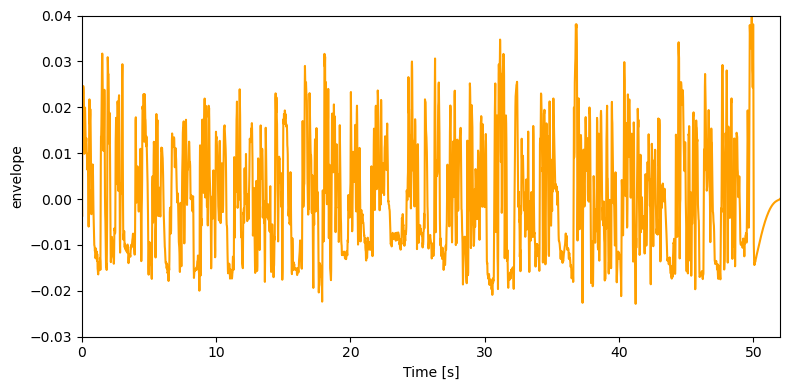

In [65]:
# 1st trial
env = load_envelope_ndvar("/Users/sylvestereley/Data/Beyond-TRFs/ds-eeg-snhl/derivatives/stimuli/sub001/target/t004woa.mat")
uts_plot = eelbrain.plot.UTS(env)

In [66]:
env_att, env_ign = load_trial_envelopes(testing_subject, trials.iloc[0], is_hi=False)
trials.iloc[0].stim_file, env_att.time, env_ign.time # see ignored (masker) starts later

('sub001/target/t004.wav',
 UTS(0.0, 0.015625, 3328),
 UTS(3.892578125, 0.015625, 3328))

In [67]:
load_predictors_for_trial(testing_subject, trials.iloc[0])

{'env_attended': <NDVar 't004~envelope': 3328 time>,
 'env_ignored': <NDVar 'm004~envelope': 3328 time>,
 'onsets_attended': <NDVar 't004~envelope_onset': 3328 time>,
 'onsets_ignored': <NDVar 'm004~envelope_onset': 3328 time>}

In [68]:
name = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, generalised=GENERALISATION_TYPE.AVERAGE)

trf = eelbrain.load.unpickle(FUGLSANG_TRF_GENERAL_DIR / f'full_{name}.pickle')

eeg_ndvar = eeg_trial_to_ndvar(eeg, trials.iloc[0], trf.h_scaled.sensor)
eeg_ndvar, eeg_ndvar.time

(<NDVar 'eeg': 64 sensor, 3327 time>, UTS(0.0, 0.015625, 3327))

In [69]:
trial_data = load_subject_trials(testing_subject, trf.h_scaled.sensor)

Loading subject sub-001 ─────────────────────────────────────────────


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_80745/3165981952.py:19: RuntimeWarning: Resampling of the stim channels caused event information to become unreliable. Consider finding events on the original data and passing the event matrix as a parameter.
  raw.resample(64)


  EEG : 64 ch  |  64.0 Hz  |  5585.0s total
  Trials found: 32
  ✓ 32/32 trials loaded
  Trial durations: min=49.9s  max=56.9s  mean=51.5s



In [70]:
trial_data[0]

{'subject': 'sub-001',
 'group': 'NH',
 'trial': 'sub001/target/t004.wav',
 'attend_side': 'attendleft',
 'difficulty': 24.0,
 'score': 75.0,
 'duration_s': 51.9375,
 'eeg': <NDVar 'eeg': 64 sensor, 3325 time>,
 'attended': <NDVar 't004~envelope': 3325 time>,
 'ignored': <NDVar 'm004~envelope': 3325 time>}